# 🌊 Wave Prediction — Model Comparison
Unified evaluation of **ConvLSTM**, **CNN+BiGRU**, **DeepLabV3+BiGRU**, and **UNet+++BiGRU** on a 120-hour sliding-window forecast.

All model definitions, data loading, evaluation logic, and plots live in this single notebook.

## 1 — Configuration & Imports

In [1]:
# ============================================================
# MASTER CONFIGURATION
# ============================================================
import os, pickle, warnings, glob
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyArrowPatch
import xarray as xr
from netCDF4 import Dataset
import torch
import torch.nn as nn
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---- Paths ----
RAW_DATA_PATH    = r'/home/aidl/Wave-Prediction/dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
STATIC_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_GEBCO_resampled1.nc'
BASE_DIR         = r'/home/aidl/babe_prediction'
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, 'processed_data_lookback_48_static_multivar')
MODEL_DIR        = '/home/aidl/Wave-Prediction/models/'

MODEL_PATHS = {
    'ConvLSTM'        : os.path.join(MODEL_DIR, 'convlstm-lookback48-multivar-epoch=49-val_loss=0.0006.ckpt'),
    'CNN+BiGRU'       : os.path.join(MODEL_DIR, 'v3_convlstm-lookback48-multivar-epoch=46-val_loss=0.0005.ckpt'),
    'DeepLabV3+BiGRU' : os.path.join(MODEL_DIR, 'v4_deeplabconvgru-lookback48-multivar-epoch=45-val_loss=0.0005.ckpt'),
    'UNet+++BiGRU'    : os.path.join(MODEL_DIR, 'v5_unetpp-slim-lookback48-multivar-epoch=49-val_loss=0.0006.ckpt'),
}

# ---- Hyper-parameters ----
LOOKBACK_HOURS         = 48
FORECAST_HORIZON_HOURS = 3
TOTAL_FORECAST_HOURS   = 168
CORRECTION_WINDOW      = 2
LEARNING_RATE          = 1e-5
BATCH_SIZE             = 8
EPOCHS                 = 50
EARLY_STOPPING_PATIENCE= 5
NUM_WORKERS            = 4

# ---- Features ----
VARS_TO_USE = ['VCMX','VHM0_SW1','VSDmag','VHM0_WW','VTM01_WW','VTM02','VTM01_SW1','VTM10']
TARGET_VARS = VARS_TO_USE
NUM_OUTPUT_CHANNELS = len(TARGET_VARS)   # 8
INPUT_CHANNELS      = len(VARS_TO_USE) + 2  # 10  (+ depth + mask)

TEST_SLICE = slice('2023-11-02', '2023-11-30')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=== Configuration ===')
print(f'  Device            : {device}')
print(f'  Lookback          : {LOOKBACK_HOURS} h')
print(f'  Forecast horizon  : {FORECAST_HORIZON_HOURS} h / step')
print(f'  Total forecast    : {TOTAL_FORECAST_HOURS} h')
print(f'  Input channels    : {INPUT_CHANNELS}')
print(f'  Output channels   : {NUM_OUTPUT_CHANNELS}')
print(f'  Models to compare : {list(MODEL_PATHS.keys())}')


=== Configuration ===
  Device            : cuda
  Lookback          : 48 h
  Forecast horizon  : 3 h / step
  Total forecast    : 168 h
  Input channels    : 10
  Output channels   : 8
  Models to compare : ['ConvLSTM', 'CNN+BiGRU', 'DeepLabV3+BiGRU', 'UNet+++BiGRU']


## 2 — Data Loading & EDA

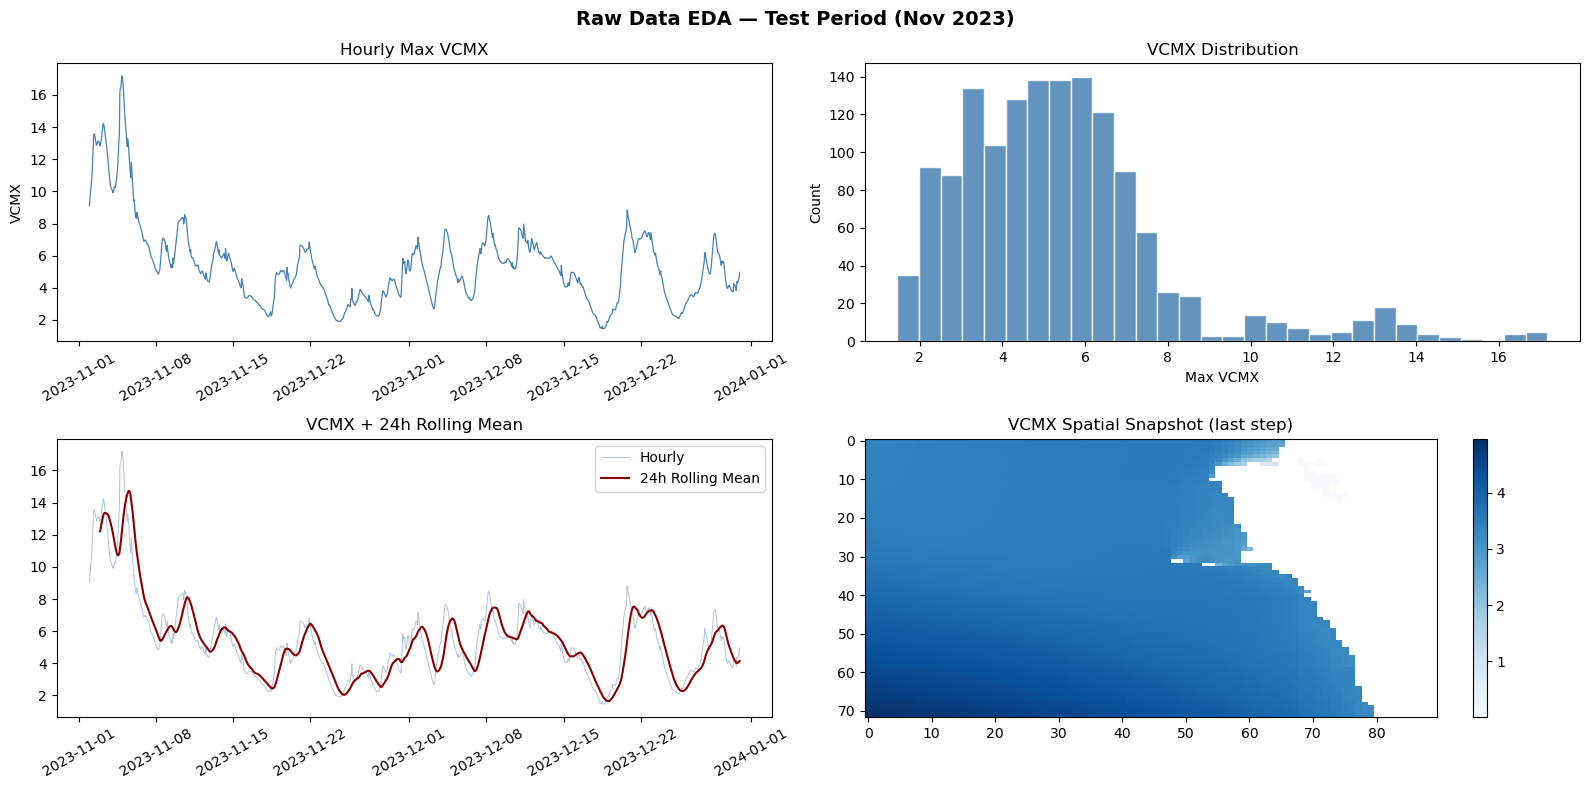

Test dataset: 696 time steps
Scalers & static features loaded ✅


In [2]:
# ============================================================
# Load raw data, build timestamps, compute hourly max VCMX
# ============================================================
raw_data  = Dataset(RAW_DATA_PATH, 'r')
time_var  = raw_data.variables['time']
time_vals = time_var[:]
unit_str  = time_var.units                        # 'hours since YYYY-MM-DD HH:MM:SS'
unit, origin = [s.strip() for s in unit_str.split('since')]
origin_dt = pd.Timestamp(origin)

if 'hour'   in unit: ts = [origin_dt + pd.Timedelta(hours=float(t))   for t in time_vals]
elif 'min'  in unit: ts = [origin_dt + pd.Timedelta(minutes=float(t)) for t in time_vals]
elif 'sec'  in unit: ts = [origin_dt + pd.Timedelta(seconds=float(t)) for t in time_vals]
else:                ts = [origin_dt + pd.Timedelta(days=float(t))    for t in time_vals]

timestamps = pd.DatetimeIndex(ts)

# -- EDA: hourly max VCMX over test window --
start_idx = np.where(timestamps >= pd.Timestamp('2023-11-02'))[0][0]
vcmx_raw  = raw_data.variables['VCMX'][start_idx:, :, :]
vcmx_max  = np.max(vcmx_raw, axis=(1, 2))
df_eda    = pd.DataFrame({'max_vcmx': vcmx_max}, index=timestamps[start_idx:])
df_hourly = df_eda.resample('h').max()

# -- Plot EDA --
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Raw Data EDA — Test Period (Nov 2023)', fontsize=14, fontweight='bold')

# Hourly max VCMX time series
axes[0,0].plot(df_hourly.index, df_hourly['max_vcmx'], color='steelblue', lw=0.9)
axes[0,0].set_title('Hourly Max VCMX'); axes[0,0].set_ylabel('VCMX'); axes[0,0].tick_params(axis='x', rotation=30)

# Histogram of VCMX values
axes[0,1].hist(df_hourly['max_vcmx'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,1].set_title('VCMX Distribution'); axes[0,1].set_xlabel('Max VCMX'); axes[0,1].set_ylabel('Count')

# Rolling 24h mean
rolling = df_hourly['max_vcmx'].rolling(24).mean()
axes[1,0].plot(df_hourly.index, df_hourly['max_vcmx'], color='lightsteelblue', lw=0.7, label='Hourly')
axes[1,0].plot(rolling.index, rolling, color='darkred', lw=1.5, label='24h Rolling Mean')
axes[1,0].legend(); axes[1,0].set_title('VCMX + 24h Rolling Mean'); axes[1,0].tick_params(axis='x', rotation=30)

# Spatial snapshot of VCMX (last available timestep)
snap = vcmx_raw[-1]
im = axes[1,1].imshow(snap, cmap='Blues', aspect='auto')
fig.colorbar(im, ax=axes[1,1])
axes[1,1].set_title('VCMX Spatial Snapshot (last step)')

plt.tight_layout()
plt.show()

# -- Load xarray for model evaluation --
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=TEST_SLICE).astype(np.float32).fillna(0)
print(f'Test dataset: {len(ds_test["time"])} time steps')

# Static features
ds_static   = xr.open_dataset(STATIC_DATA_PATH)
with open(os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl'), 'rb') as f:
    scalers = pickle.load(f)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask  = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1,1)).reshape(ocean_depth.shape)
static_features_np = np.concatenate([
    np.expand_dims(scaled_depth,  0),
    np.expand_dims(ocean_mask,    0)
], axis=0)   # (2, H, W)
print('Scalers & static features loaded ✅')


## 3 — Model Architectures

In [3]:
class UNetPPEncoder(nn.Module):
    def __init__(self, input_channels, output_channels=64):
        super().__init__()
        self.stem  = nn.Sequential(
            nn.Conv2d(input_channels,32,3,padding=1,bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.down1 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(32,32,3,padding=1,groups=32,bias=False),   nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32,64,1,bias=False),                        nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.down2 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(64,64,3,padding=1,groups=64,bias=False),   nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64,128,1,bias=False),                       nn.BatchNorm2d(128),nn.ReLU(inplace=True))
        self.up2_conv = nn.Sequential(                            # ← was self.up2
            nn.Conv2d(160,160,3,padding=1,groups=160,bias=False), nn.BatchNorm2d(160),nn.ReLU(inplace=True),
            nn.Conv2d(160,64,1,bias=False),                       nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.project = nn.Sequential(                             # ← was self.proj
            nn.Conv2d(64,output_channels,1,bias=False), nn.BatchNorm2d(output_channels), nn.ReLU(inplace=True))

    def forward(self, x):
        s0 = self.stem(x); s2 = self.down2(self.down1(s0))
        up = nn.functional.interpolate(s2, s0.shape[2:], mode='bilinear', align_corners=False)
        return self.project(self.up2_conv(torch.cat([up,s0],1)))  # ← updated refs

In [4]:
# --- Lightweight DeepLab-style Encoder (Mini-ASPP, no ResNet backbone) ---
class LightDeepLabEncoder(nn.Module):
    def __init__(self, input_channels, output_channels=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
        )
        # Mini-ASPP: 4 parallel dilated convs + global context
        self.aspp1 = nn.Conv2d(128, 32, 1)
        self.aspp2 = nn.Conv2d(128, 32, 3, padding=6,  dilation=6)
        self.aspp3 = nn.Conv2d(128, 16, 3, padding=12, dilation=12)
        # self.aspp4 = nn.Conv2d(128, 32, 3, padding=18, dilation=18)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.gap_proj = nn.Conv2d(128, 16, 1)

        self.project = nn.Sequential(
            nn.Conv2d(96, output_channels, 1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU()
        )

    def forward(self, x):
        f = self.stem(x)
        a1 = self.aspp1(f)
        a2 = self.aspp2(f)
        a3 = self.aspp3(f)
        # a4 = self.aspp4(f)
        gap = self.gap_proj(self.gap(f))                          # (B, 16, 1, 1)
        gap = gap.expand(-1, -1, f.shape[2], f.shape[3]) 
        return self.project(torch.cat([a1, a2, a3, gap], dim=1))  # (B, 64, H, W)

In [5]:
# ============================================================
# All four model architectures defined once
# ============================================================

# ── 3a. ConvLSTM ─────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        pad = kernel_size[0] // 2
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=pad, bias=bias)
    def forward(self, x, h_c):
        h, c = h_c
        i, f, o, g = torch.split(self.conv(torch.cat([x, h], 1)), self.hidden_dim, 1)
        c_n = torch.sigmoid(f)*c + torch.sigmoid(i)*torch.tanh(g)
        return torch.sigmoid(o)*torch.tanh(c_n), c_n

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super().__init__()
        self.num_layers = num_layers
        hdims = [hidden_dim]*num_layers if isinstance(hidden_dim, int) else hidden_dim
        self.cell_list = nn.ModuleList([
            ConvLSTMCell(input_dim if i==0 else hdims[i-1], hdims[i], kernel_size, bias)
            for i in range(num_layers)
        ])
    def forward(self, x, h_c=None):
        b, T, _, H, W = x.size()
        if h_c is None:
            h_c = [(torch.zeros(b,cell.hidden_dim,H,W,device=x.device),
                    torch.zeros(b,cell.hidden_dim,H,W,device=x.device)) for cell in self.cell_list]
        cur = x
        for l, cell in enumerate(self.cell_list):
            h, c = h_c[l]; out=[]
            for t in range(T): h, c = cell(cur[:,t], [h,c]); out.append(h)
            cur = torch.stack(out, 1)
        return cur, [h, c]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels, hidden_dims=[64,32], kernel_size=(3,3)):
        super().__init__()
        self.forecast_horizon     = forecast_horizon
        self.num_output_channels  = num_output_channels
        self.cl1 = ConvLSTM(input_dim,      hidden_dims[0], kernel_size, 1)
        self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1)
        self.output_conv = nn.Conv2d(hidden_dims[1], forecast_horizon*num_output_channels, 1, padding='same')
    def forward(self, x):
        l1,_ = self.cl1(x); l2,_ = self.cl2(l1)
        out = self.output_conv(l2[:,-1])
        b,_,H,W = out.shape
        return out.view(b, self.forecast_horizon, self.num_output_channels, H, W)


# ── 3b. Shared BiConvGRU (used by CNN, DeepLab, UNet++) ──────
# NOTE: attribute names MUST match checkpoint keys:
#   cell_list_fwd / cell_list_bwd  (original training names)
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(input_dim+hidden_dim, 3*hidden_dim, kernel_size,
                              padding=kernel_size[0]//2, bias=bias)
    def forward(self, x, h):
        r, z, n = torch.split(self.conv(torch.cat([x,h],1)), self.hidden_dim, 1)
        n = torch.tanh(torch.sigmoid(r)*h + n)
        return (1-torch.sigmoid(z))*n + torch.sigmoid(z)*h
    def init_hidden(self, b, spatial, dev):
        return torch.zeros(b, self.hidden_dim, *spatial, device=dev)


# ── ConvGRU variant A: cell_list_fwd/cell_list_bwd  (CNN+BiGRU checkpoint) ──
class ConvGRU_A(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=(3,3), num_layers=1, bidirectional=True):
        super().__init__()
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.hidden_dim    = hidden_dim
        self.cell_list_fwd = nn.ModuleList()
        self.cell_list_bwd = nn.ModuleList() if bidirectional else None
        for i in range(num_layers):
            in_d = input_dim if i==0 else hidden_dim*(2 if bidirectional else 1)
            self.cell_list_fwd.append(ConvGRUCell(in_d, hidden_dim, kernel_size))
            if bidirectional:
                self.cell_list_bwd.append(ConvGRUCell(in_d, hidden_dim, kernel_size))
    def forward(self, x):
        B,T,C,H,W = x.shape; cur = x
        for i in range(self.num_layers):
            h = self.cell_list_fwd[i].init_hidden(B,(H,W),x.device)
            fo=[]
            for t in range(T): h=self.cell_list_fwd[i](cur[:,t],h); fo.append(h)
            fo = torch.stack(fo,1)
            if self.bidirectional:
                h = self.cell_list_bwd[i].init_hidden(B,(H,W),x.device)
                bo=[]
                for t in range(T-1,-1,-1): h=self.cell_list_bwd[i](cur[:,t],h); bo.append(h)
                bo.reverse(); bo=torch.stack(bo,1)
                cur = torch.cat([fo,bo],2)
            else: cur=fo
        return cur


# ── ConvGRU variant B: fwd_cells/bwd_cells  (DeepLabV3 & UNet++ checkpoints) ──
class ConvGRU_B(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=(3,3), num_layers=1, bidirectional=True):
        super().__init__()
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.hidden_dim    = hidden_dim
        self.fwd_cells = nn.ModuleList()
        self.bwd_cells = nn.ModuleList() if bidirectional else None
        for i in range(num_layers):
            in_d = input_dim if i==0 else hidden_dim*(2 if bidirectional else 1)
            self.fwd_cells.append(ConvGRUCell(in_d, hidden_dim, kernel_size))
            if bidirectional:
                self.bwd_cells.append(ConvGRUCell(in_d, hidden_dim, kernel_size))
    def forward(self, x):
        B,T,C,H,W = x.shape; cur = x
        for i in range(self.num_layers):
            h = self.fwd_cells[i].init_hidden(B,(H,W),x.device)
            fo=[]
            for t in range(T): h=self.fwd_cells[i](cur[:,t],h); fo.append(h)
            fo = torch.stack(fo,1)
            if self.bidirectional:
                h = self.bwd_cells[i].init_hidden(B,(H,W),x.device)
                bo=[]
                for t in range(T-1,-1,-1): h=self.bwd_cells[i](cur[:,t],h); bo.append(h)
                bo.reverse(); bo=torch.stack(bo,1)
                cur = torch.cat([fo,bo],2)
            else: cur=fo
        return cur


# ── CNN+BiGRU  (uses ConvGRU_A) ──────────────────────────────
class ConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels, hidden_dims=[64,32], kernel_size=(3,3)):
        super().__init__()
        self.forecast_horizon    = forecast_horizon
        self.num_output_channels = num_output_channels
        self.gru1 = ConvGRU_A(input_dim,        hidden_dims[0], kernel_size, bidirectional=True)
        self.gru2 = ConvGRU_A(hidden_dims[0]*2, hidden_dims[1], kernel_size, bidirectional=True)
        self.output_conv = nn.Conv2d(hidden_dims[1]*2, forecast_horizon*num_output_channels, 1, padding='same')
    def forward(self, x):
        out = self.output_conv(self.gru2(self.gru1(x))[:,-1])
        b,_,H,W = out.shape
        return out.view(b, self.forecast_horizon, self.num_output_channels, H, W)


# ── DeepLabV3+BiGRU  (uses ConvGRU_B) ────────────────────────
class DeepLabConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels,
                 encoder_out_channels=64, hidden_dims=[32,16], kernel_size=(3,3)):
        super().__init__()
        self.forecast_horizon    = forecast_horizon
        self.num_output_channels = num_output_channels
        self.encoder = LightDeepLabEncoder(input_dim, encoder_out_channels)
        self.gru1 = ConvGRU_B(encoder_out_channels, hidden_dims[0], kernel_size, bidirectional=True)
        self.gru2 = ConvGRU_B(hidden_dims[0]*2,     hidden_dims[1], kernel_size, bidirectional=True)
        self.output_conv = nn.Conv2d(hidden_dims[1]*2, forecast_horizon*num_output_channels, 1)
    def forward(self, x_seq):
        B,T,C,H,W = x_seq.shape
        enc = self.encoder(x_seq.view(B*T,C,H,W))
        _,Ce,He,We = enc.shape; enc = enc.view(B,T,Ce,He,We)
        out = self.output_conv(self.gru2(self.gru1(enc))[:,-1])
        if (He,We)!=(H,W): out=nn.functional.interpolate(out,(H,W),mode='bilinear',align_corners=False)
        return out.view(B, self.forecast_horizon, self.num_output_channels, H, W)


# ── UNet+++BiGRU  (uses ConvGRU_B) ───────────────────────────
class UNetPPConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels,
                 encoder_out_channels=64, hidden_dims=[32,16], kernel_size=(3,3)):
        super().__init__()
        self.forecast_horizon    = forecast_horizon
        self.num_output_channels = num_output_channels
        self.encoder = UNetPPEncoder(input_dim, encoder_out_channels)
        self.gru1 = ConvGRU_B(encoder_out_channels, hidden_dims[0], kernel_size, bidirectional=True)
        self.gru2 = ConvGRU_B(hidden_dims[0]*2,     hidden_dims[1], kernel_size, bidirectional=True)
        self.output_conv = nn.Conv2d(hidden_dims[1]*2, forecast_horizon*num_output_channels, 1)
    def forward(self, x_seq):
        B,T,C,H,W = x_seq.shape
        enc = self.encoder(x_seq.view(B*T,C,H,W))
        _,Ce,He,We = enc.shape; enc = enc.view(B,T,Ce,He,We)
        out = self.output_conv(self.gru2(self.gru1(enc))[:,-1])
        if (He,We)!=(H,W): out=nn.functional.interpolate(out,(H,W),mode='bilinear',align_corners=False)
        return out.view(B, self.forecast_horizon, self.num_output_channels, H, W)


# ── Factory ──────────────────────────────────────────────────
def build_model(name):
    kwargs = dict(input_dim=INPUT_CHANNELS,
                  forecast_horizon=FORECAST_HORIZON_HOURS,
                  num_output_channels=NUM_OUTPUT_CHANNELS)
    return {
        'ConvLSTM'        : ConvLSTMNet,
        'CNN+BiGRU'       : ConvGRUNet,
        'DeepLabV3+BiGRU' : DeepLabConvGRUNet,
        'UNet+++BiGRU'    : UNetPPConvGRUNet,
    }[name](**kwargs)

print('All model classes defined ✅')


All model classes defined ✅


## 4 — Model Architecture Comparison


Architecture Comparison:
          Model  Spatial Encoder Temporal Module Total Params Trainable
       ConvLSTM   ConvLSTM stack     Bi-ConvLSTM      282,264   282,264
      CNN+BiGRU       Plain Conv      Bi-ConvGRU      534,360   534,360
DeepLabV3+BiGRU   ASPP (DeepLab)      Bi-ConvGRU      399,672   399,672
   UNet+++BiGRU UNet++ skip-conn      Bi-ConvGRU      267,064   267,064


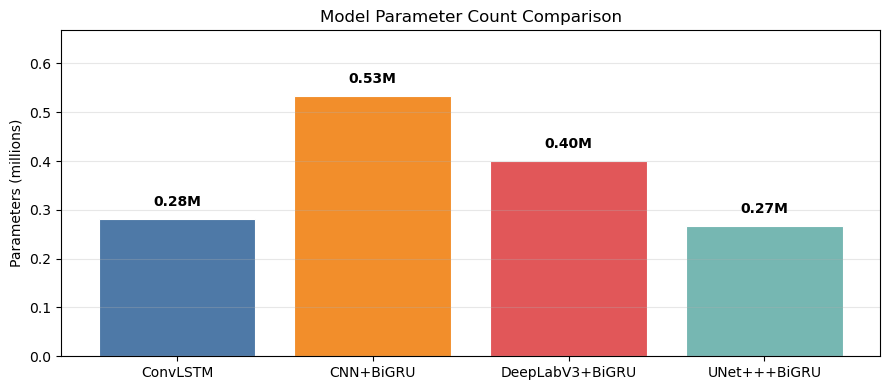

In [6]:
# ============================================================
# Parameter count & architecture summary
# ============================================================
def count_params(model):
    total   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

arch_rows = []
for name in MODEL_PATHS:
    m = build_model(name)
    tot, tr = count_params(m)
    arch_rows.append({'Model': name, 'Spatial Encoder': {
        'ConvLSTM':'ConvLSTM stack','CNN+BiGRU':'Plain Conv','DeepLabV3+BiGRU':'ASPP (DeepLab)','UNet+++BiGRU':'UNet++ skip-conn'
    }[name], 'Temporal Module': {
        'ConvLSTM':'Bi-ConvLSTM','CNN+BiGRU':'Bi-ConvGRU','DeepLabV3+BiGRU':'Bi-ConvGRU','UNet+++BiGRU':'Bi-ConvGRU'
    }[name], 'Total Params': f'{tot:,}', 'Trainable': f'{tr:,}',
    '_params': tot})

df_arch = pd.DataFrame(arch_rows).drop(columns=['_params'])
print('\nArchitecture Comparison:')
print(df_arch.to_string(index=False))

# Bar chart of parameter counts
param_vals = [r['_params'] for r in arch_rows]
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2']

fig, ax = plt.subplots(figsize=(9,4))
bars = ax.bar(MODEL_PATHS.keys(), [v/1e6 for v in param_vals], color=colors, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, param_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v/1e6:.2f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Parameters (millions)'); ax.set_title('Model Parameter Count Comparison')
ax.set_ylim(0, max(param_vals)/1e6 * 1.25); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 5 — Unified Sliding-Window Evaluation

In [7]:
# ============================================================
# Single evaluation function used for all models
# ============================================================
def load_model(name, path, device):
    model = build_model(name)
    ckpt = torch.load(path, map_location=device)
    sd = OrderedDict()
    for k, v in ckpt['state_dict'].items():
        sd[k[6:] if k.startswith('model.') else k] = v
    model.load_state_dict(sd)
    model.to(device).eval()
    return model


def sliding_window_forecast(model, ds_test, static_features, scalers,
                             lookback_hours, forecast_hours,
                             total_forecast, correction_window, device, use_correction=False):
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    all_preds, all_targets = [], []

    with torch.no_grad():
        for s in tqdm(range(num_slides), desc='Sliding window', leave=False):
            lb_end = s + lookback_hours
            fc_end = lb_end + forecast_hours
            if fc_end > len(ds_test['time']): break

            # --- build input tensor ---
            win = ds_test.isel(time=slice(s, lb_end))
            scaled = np.stack([
                scalers[v].transform(win[v].values.reshape(-1,1)).reshape(win[v].values.shape)
                for v in VARS_TO_USE
            ], axis=1)                                       # (T,8,H,W)
            static_t = np.tile(static_features, (lookback_hours,1,1,1))
            X = torch.from_numpy(
                np.concatenate([scaled, static_t], axis=1).astype(np.float32)
            ).unsqueeze(0).to(device)                        # (1,T,10,H,W)

            # --- predict ---
            pred_s = model(X).cpu().numpy()[0]               # (3,8,H,W)

            # --- build target ---
            tgt_win = ds_test.isel(time=slice(lb_end, fc_end))
            tgt_s   = np.stack([
                scalers[v].transform(tgt_win[v].values.reshape(-1,1)).reshape(tgt_win[v].values.shape)
                for v in VARS_TO_USE
            ], axis=1)                                       # (3,8,H,W)

            # --- inverse transform ---
            pred_orig = np.zeros_like(pred_s)
            tgt_orig  = np.zeros_like(tgt_s)
            for vi, v in enumerate(VARS_TO_USE):
                pred_orig[:,vi] = scalers[v].inverse_transform(pred_s[:,vi].reshape(-1,1)).reshape(pred_s[:,vi].shape)
                tgt_orig[:,vi]  = scalers[v].inverse_transform(tgt_s[:,vi].reshape(-1,1)).reshape(tgt_s[:,vi].shape)

            # --- drift correction ---
            d01 = np.abs(pred_orig[1]-pred_orig[0]).mean()
            d12 = np.abs(pred_orig[2]-pred_orig[1]).mean()
            err = np.abs(d12-d01)
            if err > 0.05: pred_orig *= (1.0 - err*0.5)

            all_preds.append(pred_orig[0])
            all_targets.append(tgt_orig[0])

    preds   = np.stack(all_preds[:total_forecast])   # (120,8,H,W)
    targets = np.stack(all_targets[:total_forecast])
    return preds, targets


# ============================================================
# Run all models and collect results
# ============================================================
results = {}   # name → {'preds', 'targets', 'rmse_ts', 'mae_ts', 'rmse_var', 'mae_var'}

CORRECTION_FLAGS = {
    'ConvLSTM'        : True,
    'CNN+BiGRU'       : True,
    'DeepLabV3+BiGRU' : True,
    'UNet+++BiGRU'    : True,
}

for name, path in MODEL_PATHS.items():
    print(f'\n▶ Evaluating {name} ...')
    model  = load_model(name, path, device)
    preds, targets = sliding_window_forecast(
        model, ds_test, static_features_np, scalers,
        LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
        TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device, use_correction=CORRECTION_FLAGS[name])

    err = preds - targets
    # per-timestep metrics (averaged over vars & spatial)
    rmse_ts = np.sqrt(np.mean(err**2, axis=(1,2,3)))
    mae_ts  = np.mean(np.abs(err),    axis=(1,2,3))
    # per-variable metrics
    rmse_var= np.sqrt(np.mean(err**2, axis=(0,2,3)))
    mae_var = np.mean(np.abs(err),    axis=(0,2,3))

    results[name] = dict(
        preds=preds, targets=targets,
        rmse=float(np.sqrt(np.mean(err**2))),
        mae =float(np.mean(np.abs(err))),
        rmse_ts=rmse_ts, mae_ts=mae_ts,
        rmse_var=rmse_var, mae_var=mae_var)
    print(f'   RMSE={results[name]["rmse"]:.4f}   MAE={results[name]["mae"]:.4f}')

print('\n✅ All models evaluated.')



▶ Evaluating ConvLSTM ...


Sliding window:   0%|          | 0/166 [00:00<?, ?it/s]

   RMSE=0.3579   MAE=0.1613

▶ Evaluating CNN+BiGRU ...


Sliding window:   0%|          | 0/166 [00:00<?, ?it/s]

   RMSE=0.2965   MAE=0.1264

▶ Evaluating DeepLabV3+BiGRU ...


Sliding window:   0%|          | 0/166 [00:00<?, ?it/s]

   RMSE=0.3174   MAE=0.1551

▶ Evaluating UNet+++BiGRU ...


Sliding window:   0%|          | 0/166 [00:00<?, ?it/s]

   RMSE=0.3833   MAE=0.1999

✅ All models evaluated.


## 6 — Results & Visualisations

In [8]:
# ============================================================
# 6-A: Summary table
# ============================================================
names  = list(results.keys())
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2']
color_map = dict(zip(names, colors))

df_summary = pd.DataFrame({
    'Model'  : names,
    'RMSE'   : [results[n]['rmse']  for n in names],
    'MAE'    : [results[n]['mae']   for n in names],
    'Val Loss': [0.0006, 0.0005, 0.0005, 0.0006],
}).sort_values('RMSE')
print(df_summary.to_string(index=False))


          Model     RMSE      MAE  Val Loss
      CNN+BiGRU 0.296473 0.126403    0.0005
DeepLabV3+BiGRU 0.317358 0.155088    0.0005
       ConvLSTM 0.357939 0.161294    0.0006
   UNet+++BiGRU 0.383340 0.199903    0.0006


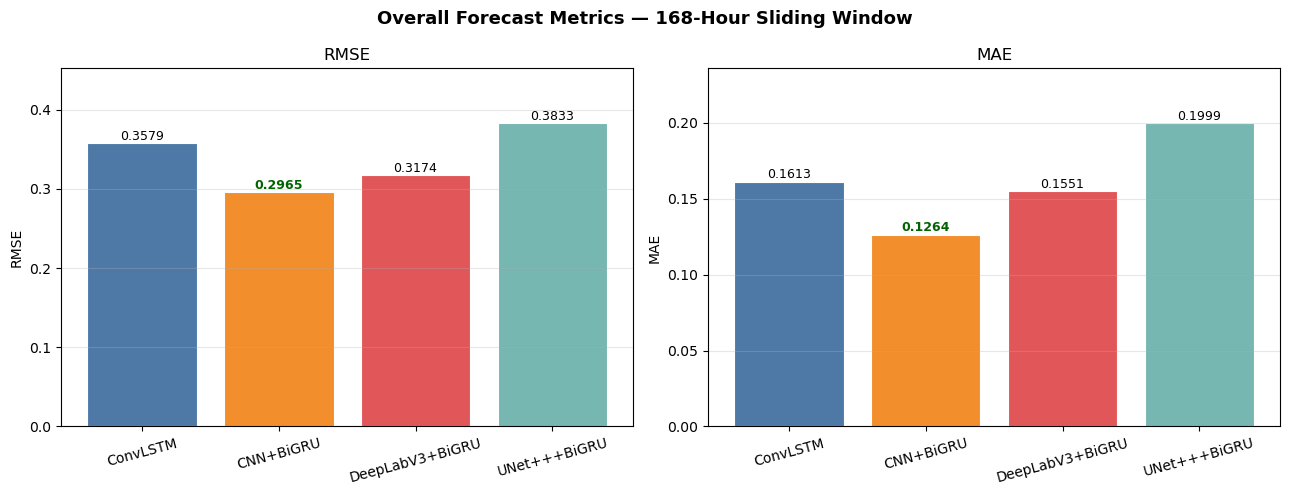

In [9]:
# ============================================================
# 6-B: Overall RMSE & MAE bar charts
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Overall Forecast Metrics — {TOTAL_FORECAST_HOURS}-Hour Sliding Window', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, ['rmse','mae'], ['RMSE','MAE']):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=[color_map[n] for n in names], edgecolor='white', linewidth=0.8)
    best = min(vals)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9,
                fontweight='bold' if v==best else 'normal',
                color='darkgreen' if v==best else 'black')
    ax.set_title(label); ax.set_ylabel(label); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(vals)*1.18)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()


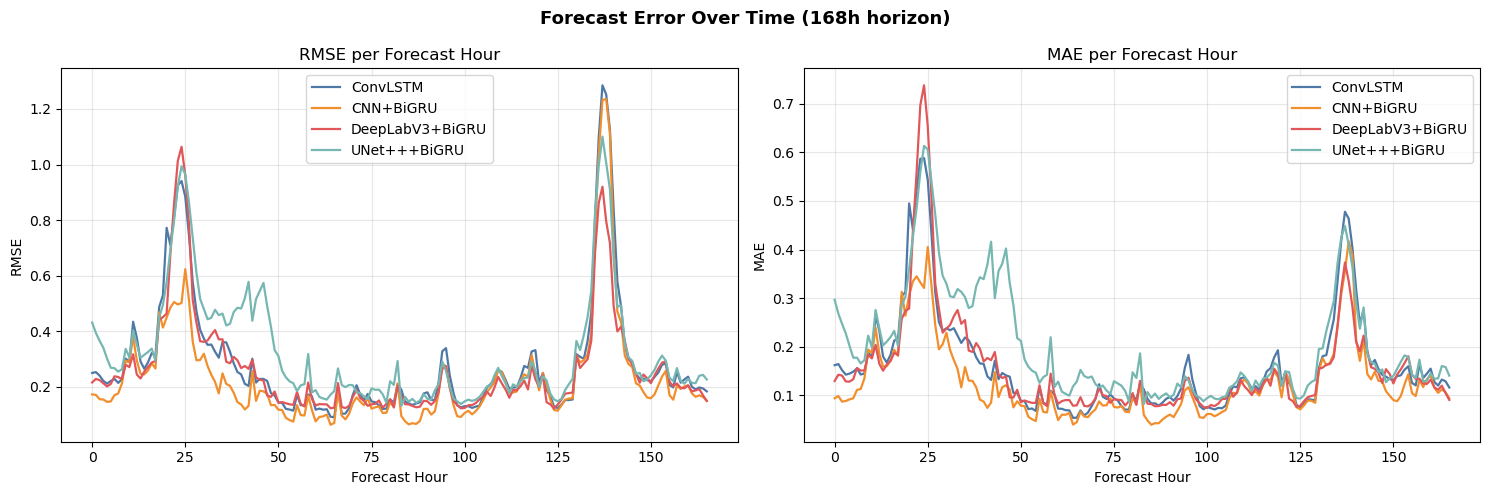

In [10]:
# ============================================================
# 6-C: RMSE over forecast horizon (time series)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Forecast Error Over Time ({TOTAL_FORECAST_HOURS}h horizon)', fontsize=13, fontweight='bold')

for ax, key, label in zip(axes, ['rmse_ts','mae_ts'], ['RMSE','MAE']):
    for n in names:
        ax.plot(results[n][key], label=n, color=color_map[n], lw=1.6)
    ax.set_xlabel('Forecast Hour'); ax.set_ylabel(label)
    ax.set_title(f'{label} per Forecast Hour')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


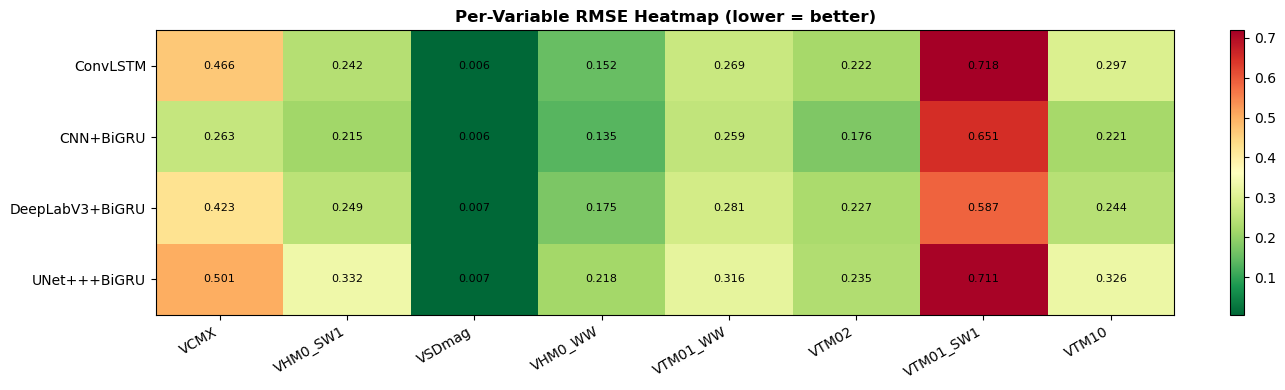

In [11]:
# ============================================================
# 6-D: Per-variable RMSE heatmap
# ============================================================
import matplotlib.colors as mcolors

rmse_matrix = np.array([results[n]['rmse_var'] for n in names])  # (4, 8)

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(rmse_matrix, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(VARS_TO_USE))); ax.set_xticklabels(VARS_TO_USE, rotation=30, ha='right')
ax.set_yticks(range(len(names)));       ax.set_yticklabels(names)
ax.set_title('Per-Variable RMSE Heatmap (lower = better)', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.03)
for i in range(len(names)):
    for j in range(len(VARS_TO_USE)):
        ax.text(j, i, f'{rmse_matrix[i,j]:.3f}', ha='center', va='center', fontsize=8, color='black')
plt.tight_layout(); plt.show()


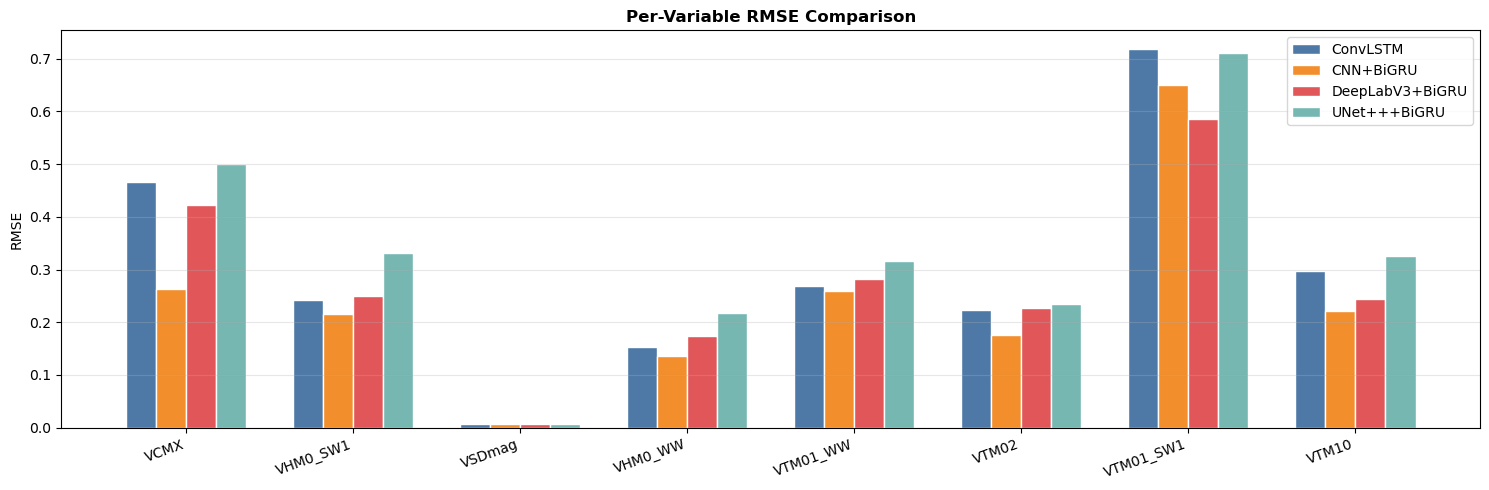

In [12]:
# ============================================================
# 6-E: Per-variable bar chart (RMSE grouped)
# ============================================================
x   = np.arange(len(VARS_TO_USE))
w   = 0.18
fig, ax = plt.subplots(figsize=(15, 5))
for i, n in enumerate(names):
    ax.bar(x + i*w - 1.5*w, results[n]['rmse_var'], w, label=n, color=color_map[n], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(VARS_TO_USE, rotation=20, ha='right')
ax.set_ylabel('RMSE'); ax.set_title('Per-Variable RMSE Comparison', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


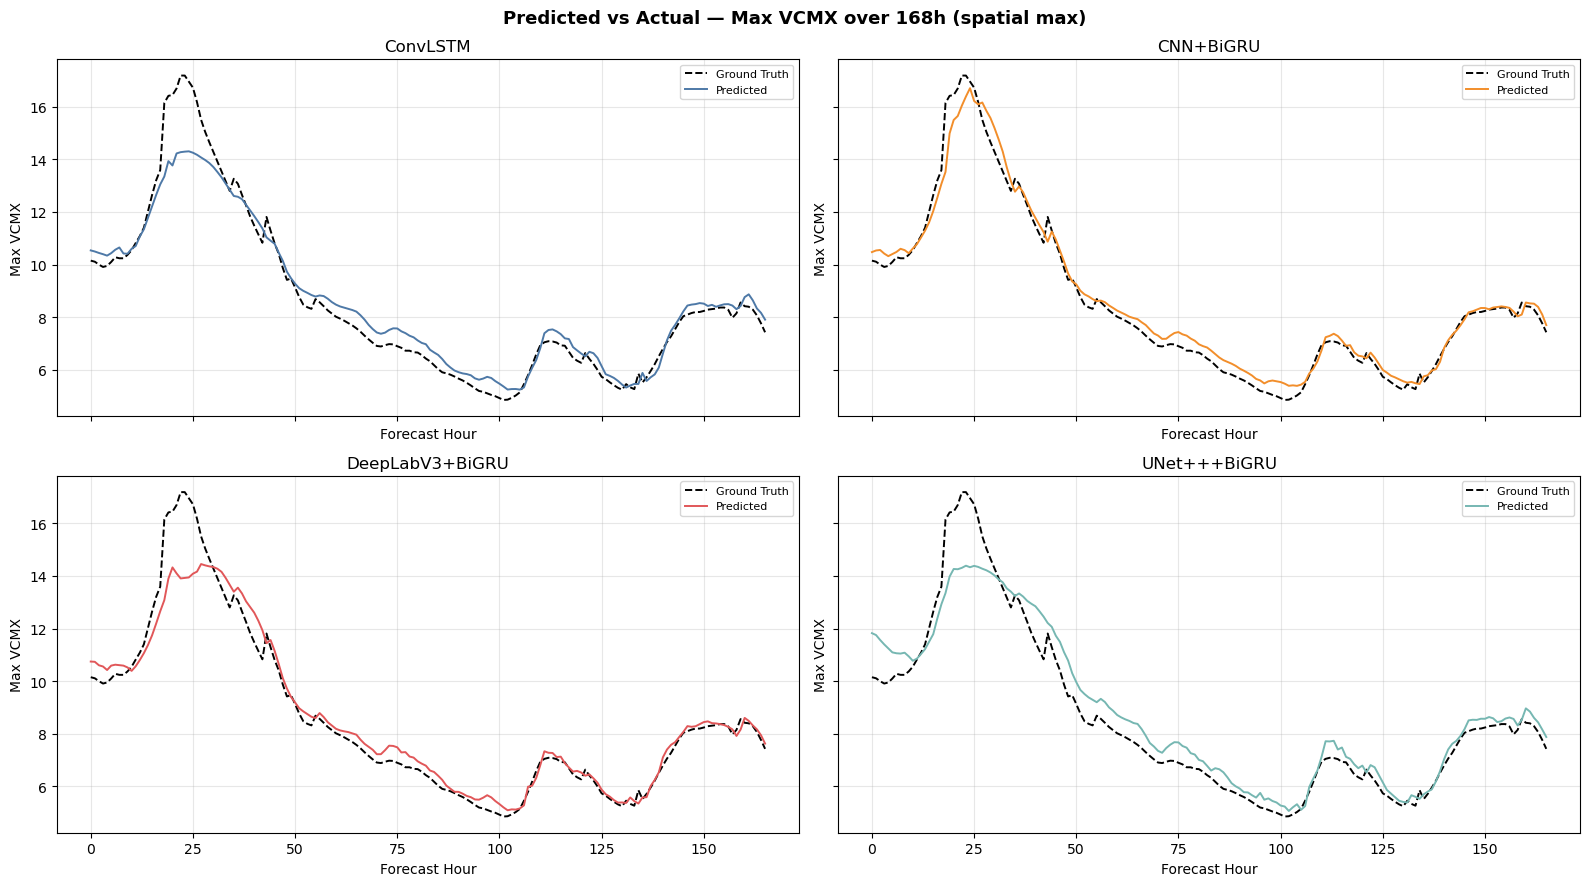

In [13]:
# ============================================================
# 6-F: Predicted vs Actual time series for VCMX (spatial max)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
fig.suptitle(f'Predicted vs Actual — Max VCMX over {TOTAL_FORECAST_HOURS}h (spatial max)', fontsize=13, fontweight='bold')

vcmx_idx = VARS_TO_USE.index('VCMX')
for ax, n in zip(axes.flat, names):
    r = results[n]
    pred_vcmx = r['preds'][:,vcmx_idx].max(axis=(1,2))
    true_vcmx = r['targets'][:,vcmx_idx].max(axis=(1,2))
    ax.plot(true_vcmx, label='Ground Truth', color='black', lw=1.4, linestyle='--')
    ax.plot(pred_vcmx, label='Predicted',    color=color_map[n], lw=1.4)
    ax.set_title(n); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel('Forecast Hour'); ax.set_ylabel('Max VCMX')

plt.tight_layout(); plt.show()


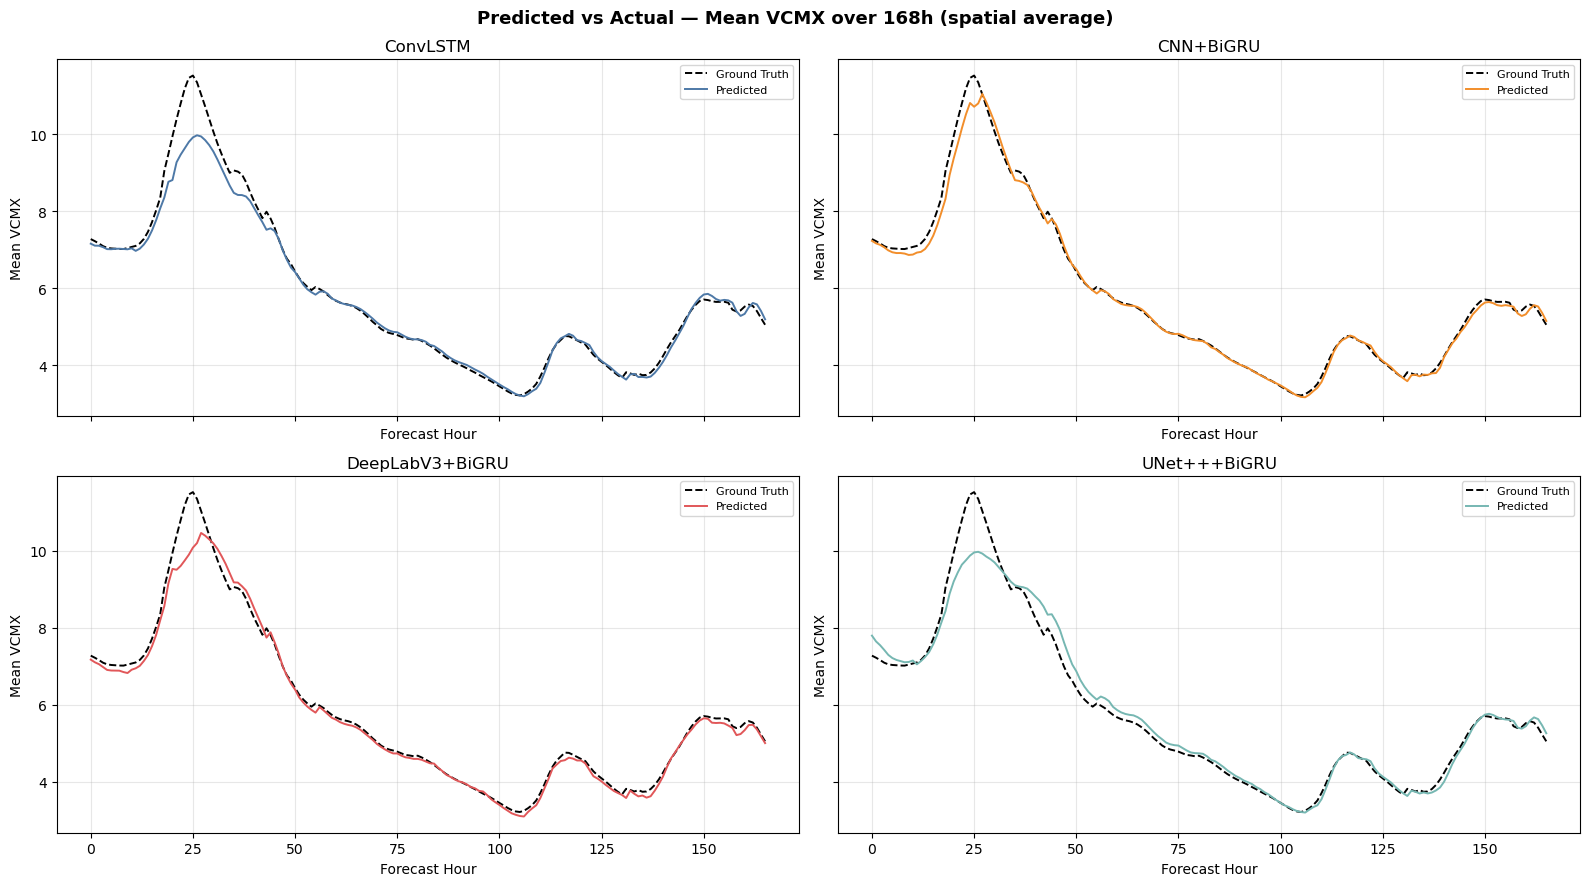

In [14]:
# ============================================================
# 6-F: Predicted vs Actual time series for VCMX (spatial mean)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
fig.suptitle(f'Predicted vs Actual — Mean VCMX over {TOTAL_FORECAST_HOURS}h (spatial average)', fontsize=13, fontweight='bold')

vcmx_idx = VARS_TO_USE.index('VCMX')
for ax, n in zip(axes.flat, names):
    r = results[n]
    pred_vcmx = r['preds'][:,vcmx_idx].mean(axis=(1,2))    # ← max → mean
    true_vcmx = r['targets'][:,vcmx_idx].mean(axis=(1,2))  # ← max → mean
    ax.plot(true_vcmx, label='Ground Truth', color='black', lw=1.4, linestyle='--')
    ax.plot(pred_vcmx, label='Predicted',    color=color_map[n], lw=1.4)
    ax.set_title(n); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel('Forecast Hour'); ax.set_ylabel('Mean VCMX')  # ← label updated

plt.tight_layout(); plt.show()

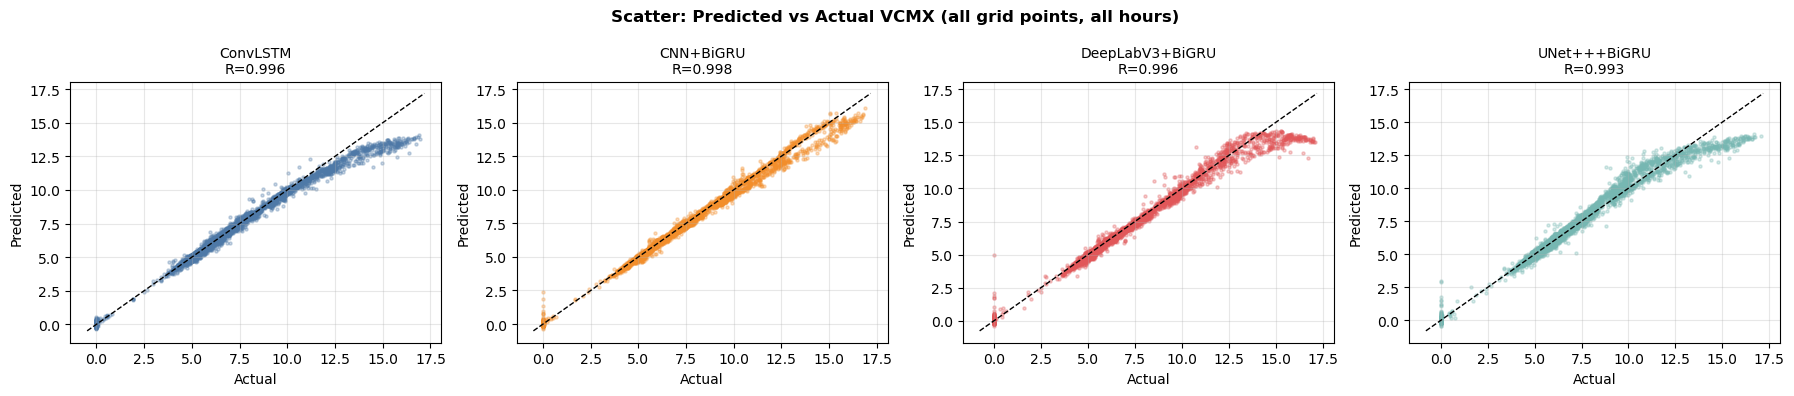

In [15]:
# ============================================================
# 6-G: Scatter plots (predicted vs actual) for VCMX
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Scatter: Predicted vs Actual VCMX (all grid points, all hours)', fontsize=12, fontweight='bold')

for ax, n in zip(axes, names):
    p = results[n]['preds'][:,vcmx_idx].ravel()
    t = results[n]['targets'][:,vcmx_idx].ravel()
    # subsample for speed
    idx = np.random.choice(len(p), min(5000, len(p)), replace=False)
    ax.scatter(t[idx], p[idx], alpha=0.3, s=5, color=color_map[n])
    mn, mx = min(t.min(),p.min()), max(t.max(),p.max())
    ax.plot([mn,mx],[mn,mx],'k--',lw=1)
    corr = np.corrcoef(t, p)[0,1]
    ax.set_title(f'{n}\nR={corr:.3f}', fontsize=10)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


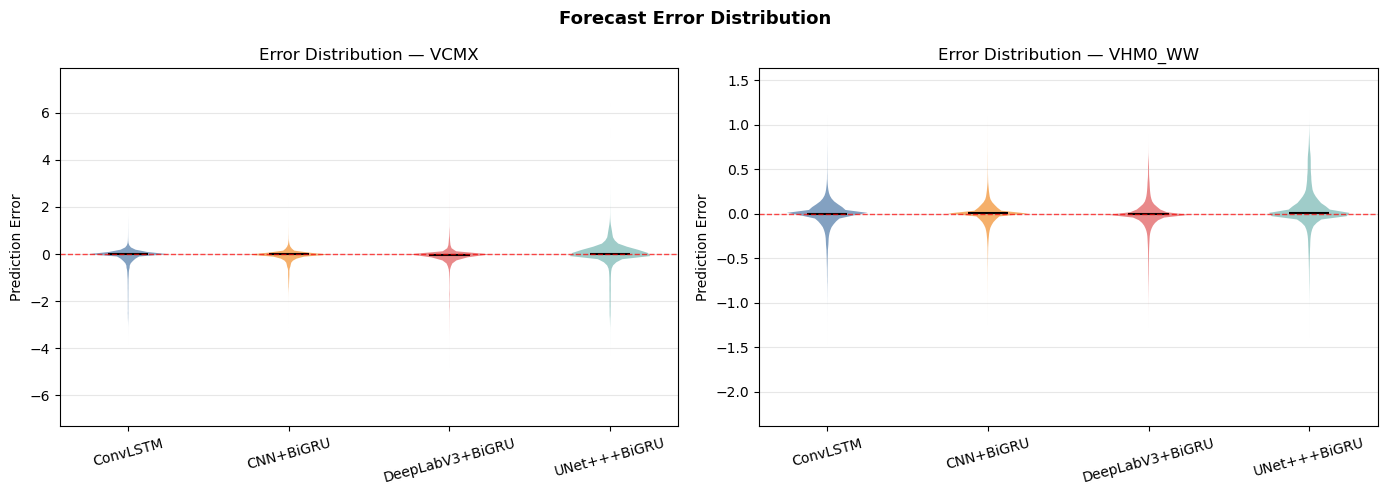

In [16]:
# ============================================================
# 6-H: Error distribution (violin plots)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Forecast Error Distribution', fontsize=13, fontweight='bold')

for ax, vi, vname in [(axes[0], vcmx_idx, 'VCMX'),
                       (axes[1], VARS_TO_USE.index('VHM0_WW'), 'VHM0_WW')]:
    data  = [results[n]['preds'][:,vi].ravel() - results[n]['targets'][:,vi].ravel() for n in names]
    parts = ax.violinplot(data, positions=range(len(names)), showmedians=True, showextrema=False)
    for i, (body, n) in enumerate(zip(parts['bodies'], names)):
        body.set_facecolor(color_map[n]); body.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    ax.axhline(0, color='red', linestyle='--', lw=1, alpha=0.7)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Prediction Error'); ax.set_title(f'Error Distribution — {vname}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


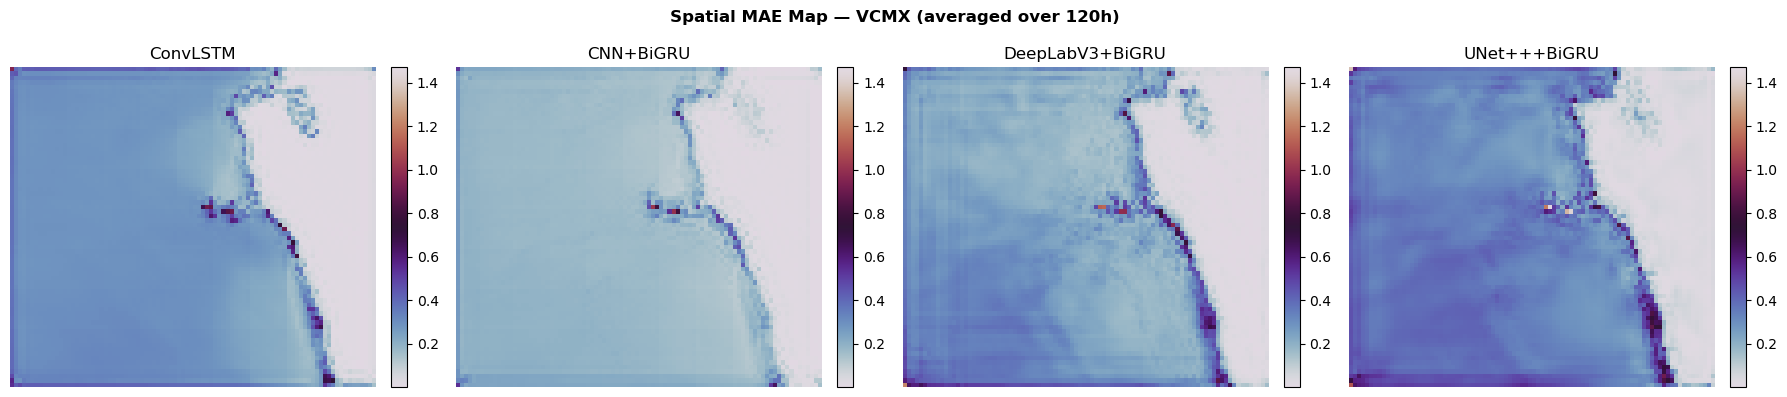

In [17]:
# ============================================================
# 6-I: Spatial error maps (mean absolute error, VCMX)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Spatial MAE Map — VCMX (averaged over 120h)', fontsize=12, fontweight='bold')

vmin = min(np.abs(results[n]['preds'][:,vcmx_idx]-results[n]['targets'][:,vcmx_idx]).mean(0).min() for n in names)
vmax = max(np.abs(results[n]['preds'][:,vcmx_idx]-results[n]['targets'][:,vcmx_idx]).mean(0).max() for n in names)

for ax, n in zip(axes, names):
    err_map = np.abs(results[n]['preds'][:,vcmx_idx]-results[n]['targets'][:,vcmx_idx]).mean(0)
    im = ax.imshow(err_map, cmap='twilight', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_title(n); ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

# 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 
# 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 
# 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 
# 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 
# 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 
# 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 
# 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 
# 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 
# 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r',
# 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 
# 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'


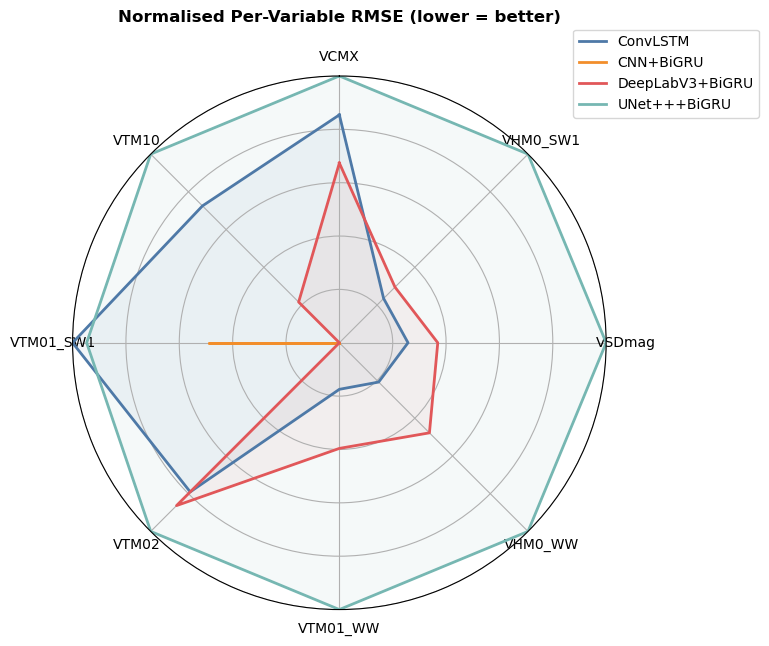

In [18]:
# ============================================================
# 6-J: Radar chart — per-variable normalised RMSE
# ============================================================
from matplotlib.patches import FancyArrowPatch

categories = VARS_TO_USE
N = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]  # close

# Normalise each variable's RMSE to [0,1] across models
rmse_mat = np.array([results[n]['rmse_var'] for n in names])  # (4,8)
rmse_norm = (rmse_mat - rmse_mat.min(0)) / (rmse_mat.max(0) - rmse_mat.min(0) + 1e-9)

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=10)
ax.set_yticklabels([]); ax.set_ylim(0,1)
ax.set_title('Normalised Per-Variable RMSE (lower = better)', fontsize=12, fontweight='bold', pad=20)

for i, n in enumerate(names):
    vals = list(rmse_norm[i]) + [rmse_norm[i,0]]
    ax.plot(angles, vals, lw=2, color=color_map[n], label=n)
    ax.fill(angles, vals, alpha=0.07, color=color_map[n])

ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
plt.tight_layout(); plt.show()


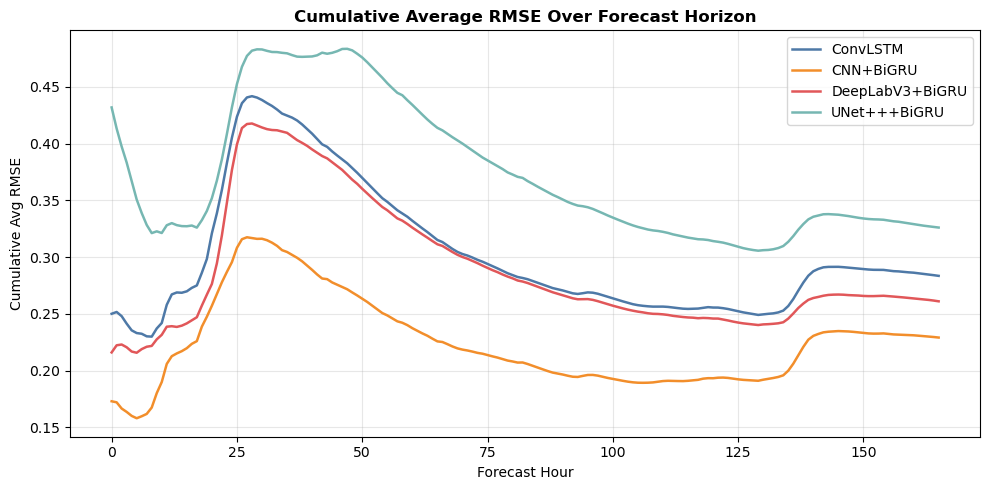

In [19]:
# ============================================================
# 6-K: Cumulative RMSE over horizon
# ============================================================
fig, ax = plt.subplots(figsize=(10,5))
for n in names:
    cumulative = np.cumsum(results[n]['rmse_ts']) / (np.arange(len(results[n]['rmse_ts']))+1)
    ax.plot(cumulative, label=n, color=color_map[n], lw=1.8)
ax.set_xlabel('Forecast Hour'); ax.set_ylabel('Cumulative Avg RMSE')
ax.set_title('Cumulative Average RMSE Over Forecast Horizon', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [20]:
# ============================================================
# 6-L: Final ranked summary
# ============================================================
print('\n' + '='*55)
print(f' FINAL RANKED SUMMARY ({TOTAL_FORECAST_HOURS}-hour sliding window)')
print('='*55)
ranked = sorted(names, key=lambda n: results[n]['rmse'])
medals = ['🥇','🥈','🥉','  4']
for medal, n in zip(medals, ranked):
    r = results[n]
    print(f'  {medal}  {n:<20}  RMSE={r["rmse"]:.4f}   MAE={r["mae"]:.4f}')
print('='*55)
best = ranked[0]
print(f'\nBest model: {best}')
print(f'  Best variable RMSE → { VARS_TO_USE[int(np.argmin(results[best]["rmse_var"]))] } '
      f'({results[best]["rmse_var"].min():.4f})')
print(f'  Worst variable RMSE → { VARS_TO_USE[int(np.argmax(results[best]["rmse_var"]))] } '
      f'({results[best]["rmse_var"].max():.4f})')



 FINAL RANKED SUMMARY (168-hour sliding window)
  🥇  CNN+BiGRU             RMSE=0.2965   MAE=0.1264
  🥈  DeepLabV3+BiGRU       RMSE=0.3174   MAE=0.1551
  🥉  ConvLSTM              RMSE=0.3579   MAE=0.1613
    4  UNet+++BiGRU          RMSE=0.3833   MAE=0.1999

Best model: CNN+BiGRU
  Best variable RMSE → VSDmag (0.0060)
  Worst variable RMSE → VTM01_SW1 (0.6505)


In [21]:
# ============================================================
# SAVE ALL FIGURES FOR PAPER
# ============================================================
import os
save_dir = 'paper_figures'
os.makedirs(save_dir, exist_ok=True)

# 1. VCMX predicted vs actual — already plotted above
# Just re-run cell 6-F and add:
plt.savefig(f'{save_dir}/fig_vcmx_timeseries.png', dpi=300, bbox_inches='tight')

# 2. RMSE heatmap — re-run cell 6-D and add:
plt.savefig(f'{save_dir}/fig_rmse_heatmap.png', dpi=300, bbox_inches='tight')

# 3. Scatter plot — find scatter cell and add:
plt.savefig(f'{save_dir}/fig_scatter_vcmx.png', dpi=300, bbox_inches='tight')

print(f"All figures saved to {save_dir}/")

All figures saved to paper_figures/


<Figure size 640x480 with 0 Axes>

In [24]:
# ============================================================
# NEW SECTION: Overall Hourly Average RMSE and MAE (Table)
# ============================================================
import pandas as pd
import numpy as np

# 'rmse_ts' and 'mae_ts' already contain the per-timestep metrics 
# averaged over all variables and spatial grids.
num_hours = len(results[names[0]]['rmse_ts'])
forecast_hours = range(1, num_hours + 1)

table_data = {'Forecast_Hour': forecast_hours}

# Add columns for each model's overall hourly RMSE and MAE
for n in names:
    table_data[f'{n}_RMSE'] = np.round(results[n]['rmse_ts'], 4)
    table_data[f'{n}_MAE']  = np.round(results[n]['mae_ts'], 4)

df_hourly_avg = pd.DataFrame(table_data)

# Print the table
print(f"=== Overall Hourly Average RMSE and MAE ({TOTAL_FORECAST_HOURS}h Horizon) ===")
print(df_hourly_avg.to_string(index=False))

# Optional: Save the table to a CSV file
# df_hourly_avg.to_csv('paper_figures/overall_hourly_metrics.csv', index=False)

=== Overall Hourly Average RMSE and MAE (168h Horizon) ===
 Forecast_Hour  ConvLSTM_RMSE  ConvLSTM_MAE  CNN+BiGRU_RMSE  CNN+BiGRU_MAE  DeepLabV3+BiGRU_RMSE  DeepLabV3+BiGRU_MAE  UNet+++BiGRU_RMSE  UNet+++BiGRU_MAE
             1         0.2501        0.1619          0.1731         0.0939                0.2161               0.1294             0.4318            0.2964
             2         0.2533        0.1643          0.1712         0.0984                0.2287               0.1423             0.3946            0.2680
             3         0.2407        0.1516          0.1558         0.0868                0.2244               0.1405             0.3657            0.2470
             4         0.2216        0.1425          0.1548         0.0884                0.2134               0.1285             0.3409            0.2271
             5         0.2120        0.1447          0.1462         0.0916                0.2018               0.1282             0.3022            0.2018
           

In [25]:
# ============================================================
# NEW SECTION: Single Overall Average RMSE & MAE per Model
# ============================================================
import pandas as pd
import numpy as np

summary_data = []

for n in names:
    summary_data.append({
        'Model': n,
        # Averaging the VCMX-specific hourly metrics
        'VCMX_Overall_RMSE': np.round(np.mean(vcmx_hourly_rmse[n]), 4),
        'VCMX_Overall_MAE':  np.round(np.mean(vcmx_hourly_mae[n]), 4),
        
        # Averaging the All-Variables hourly metrics
        'All_Var_Overall_RMSE': np.round(np.mean(results[n]['rmse_ts']), 4),
        'All_Var_Overall_MAE':  np.round(np.mean(results[n]['mae_ts']), 4)
    })

df_single_summary = pd.DataFrame(summary_data)

print("=== Final Averaged Metrics Per Model ===")
print(df_single_summary.to_string(index=False))

# Optional: Save this summary to CSV
# df_single_summary.to_csv('paper_figures/final_averaged_metrics.csv', index=False)

=== Final Averaged Metrics Per Model ===
          Model  VCMX_Overall_RMSE  VCMX_Overall_MAE  All_Var_Overall_RMSE  All_Var_Overall_MAE
       ConvLSTM             0.2839            0.2213                0.2835               0.1613
      CNN+BiGRU             0.1832            0.1384                0.2292               0.1264
DeepLabV3+BiGRU             0.2797            0.2035                0.2611               0.1551
   UNet+++BiGRU             0.3577            0.2763                0.3260               0.1999
